### MLP Model made using PyTorch
Relevant Statistics: Made via MLP with 7 layers 1024->output

#### 3-Folds
| Category          | Accuracy            | Precision          | Recall             | F1                  | ROC_AUC             |
|-------------------|---------------------|--------------------|--------------------|---------------------|---------------------|
| any               | 0.8363 ± 0.0044     | 0.8027 ± 0.0203    | 0.8048 ± 0.0241    | 0.8034 ± 0.0035     | 0.9019 ± 0.0016     |
| epidural          | 0.7275 ± 0.0328     | 0.0345 ± 0.0005    | 0.5799 ± 0.0792    | 0.0651 ± 0.0011     | 0.7302 ± 0.0042     |
| intraparenchymal  | 0.7302 ± 0.0164     | 0.4813 ± 0.0214    | 0.8072 ± 0.0287    | 0.6025 ± 0.0099     | 0.8141 ± 0.0027     |
| intraventricular  | 0.6832 ± 0.0203     | 0.3388 ± 0.0115    | 0.8046 ± 0.0258    | 0.4765 ± 0.0075     | 0.7834 ± 0.0041     |
| subarachnoid      | 0.6951 ± 0.0086     | 0.3592 ± 0.0166    | 0.8042 ± 0.0337    | 0.4965 ± 0.0203     | 0.7893 ± 0.0104     |
| subdural          | 0.6920 ± 0.0076     | 0.3560 ± 0.0083    | 0.8212 ± 0.0215    | 0.4967 ± 0.0120     | 0.7900 ± 0.0063     |

#### 5-Folds
| Category          | Accuracy            | Precision          | Recall             | F1                  | ROC_AUC             |
|-------------------|---------------------|--------------------|--------------------|---------------------|---------------------|
| any               | 0.8383 ± 0.0063     | 0.8115 ± 0.0296    | 0.7984 ± 0.0306    | 0.8040 ± 0.0047     | 0.9052 ± 0.0054     |
| epidural          | 0.7255 ± 0.0163     | 0.0351 ± 0.0054    | 0.5999 ± 0.0897    | 0.0661 ± 0.0097     | 0.7389 ± 0.0336     |
| intraparenchymal  | 0.7353 ± 0.0135     | 0.4868 ± 0.0158    | 0.7977 ± 0.0242    | 0.6042 ± 0.0067     | 0.8150 ± 0.0058     |
| intraventricular  | 0.6906 ± 0.0184     | 0.3436 ± 0.0159    | 0.7943 ± 0.0260    | 0.4792 ± 0.0110     | 0.7850 ± 0.0061     |
| subarachnoid      | 0.7011 ± 0.0166     | 0.3653 ± 0.0207    | 0.8026 ± 0.0305    | 0.5013 ± 0.0136     | 0.7923 ± 0.0088     |
| subdural          | 0.7005 ± 0.0222     | 0.3622 ± 0.0259    | 0.8012 ± 0.0185    | 0.4981 ± 0.0211     | 0.7919 ± 0.0109     |

#### 10-Folds
| Category          | Accuracy            | Precision          | Recall             | F1                  | ROC_AUC             |
|-------------------|---------------------|--------------------|--------------------|---------------------|---------------------|
| any               | 0.8357 ± 0.0150     | 0.8001 ± 0.0304    | 0.8080 ± 0.0188    | 0.8035 ± 0.0136     | 0.9053 ± 0.0099     |
| epidural          | 0.7060 ± 0.0350     | 0.0330 ± 0.0053    | 0.6071 ± 0.1250    | 0.0626 ± 0.0099     | 0.7354 ± 0.0506     |
| intraparenchymal  | 0.7320 ± 0.0162     | 0.4828 ± 0.0177    | 0.8056 ± 0.0248    | 0.6034 ± 0.0145     | 0.8155 ± 0.0138     |
| intraventricular  | 0.6861 ± 0.0216     | 0.3418 ± 0.0156    | 0.8093 ± 0.0180    | 0.4803 ± 0.0141     | 0.7863 ± 0.0128     |
| subarachnoid      | 0.6952 ± 0.0203     | 0.3614 ± 0.0209    | 0.8168 ± 0.0225    | 0.5006 ± 0.0192     | 0.7942 ± 0.0152     |
| subdural          | 0.6905 ± 0.0257     | 0.3548 ± 0.0271    | 0.8127 ± 0.0207    | 0.4934 ± 0.0254     | 0.7925 ± 0.0170     |



# Hemorrhage Detection MLP Model K-Fold Evaluation

This notebook loads the optimized MLP model from the saved weights and evaluates it using K-fold cross-validation with k={3,5,10}. The process follows these steps:

1. Setup and Data Preparation
2. Load Pre-trained Model and Hyperparameters
3. K-Fold Cross Validation
4. Performance Analysis and Visualization
5. Statistical Comparison of Different K-Folds

## 1. Setup and Data Preparation

In [21]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [23]:
# Load the datasets into pandas DataFrames
df_hemo = pd.read_csv('../Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('../Rsna_ICH_Control.csv')

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

print(f"Full dataset shape: X={X.shape}, y={y.shape}")

Full dataset shape: X=(16125, 1408), y=(16125, 6)


In [24]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

class HemorrhageMLP(nn.Module):
    """Dynamic MLP model for hemorrhage detection."""
    def __init__(self, input_size, output_size, layer_sizes, dropout_rates):
        super(HemorrhageMLP, self).__init__()

        layers = []
        prev_size = input_size

        for i, size in enumerate(layer_sizes):
            layers.append(nn.Linear(prev_size, size))
            layers.append(nn.BatchNorm1d(size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rates[i]))
            prev_size = size

        layers.append(nn.Linear(prev_size, output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
import time

# Load hyperparameters from your saved JSON file
params_path = 'model_saves/model_hyperparameters.json'
with open(params_path, 'r') as f:
    hyperparams = json.load(f)

best_lr = hyperparams['learning_rate']
best_layer_sizes = hyperparams['layer_sizes']
best_dropout_rates = hyperparams['dropout_rates']
input_size = hyperparams['input_size']
output_size = hyperparams['output_size']

print("Loaded hyperparameters:")
print(json.dumps(hyperparams, indent=2))

k_folds_list = [3, 5, 10]
all_metrics_list = []
num_epochs = 50  # Max epochs per fold (will stop early)
patience = 5     # Early stopping patience

def calculate_specificity(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# --- Outer loop for K (3, 5, 10) ---
for n_splits in k_folds_list:
    print(f"\n{'='*30}")
    print(f"STARTING K={n_splits} FOLD CROSS-VALIDATION")
    print(f"{'='*30}")
    
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # --- Inner loop for each fold ---
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        print(f"\n--- Fold {fold+1}/{n_splits} ---")
        start_time = time.time()
        
        # 1. Split data for this fold
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        
        # 2. Scale features (Fit on train, transform train/val)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # 3. Calculate class weights for this training fold
        pos_weights = []
        for i in range(len(target_columns)):
            num_pos = np.sum(y_train[:, i])
            num_neg = y_train.shape[0] - num_pos
            weight = num_neg / (num_pos + 1e-6)
            pos_weights.append(weight)
        pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)
        
        # 4. Create Tensors and DataLoaders
        train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), 
                                      torch.tensor(y_train, dtype=torch.float32))
        val_dataset = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32), 
                                    torch.tensor(y_val, dtype=torch.float32))
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32)
        
        # 5. Initialize model, criterion, and optimizer
        model = HemorrhageMLP(
            input_size=input_size,
            output_size=output_size,
            layer_sizes=best_layer_sizes,
            dropout_rates=best_dropout_rates
        ).to(device)
        
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
        optimizer = optim.Adam(model.parameters(), lr=best_lr)
        early_stopper = EarlyStopping(patience=patience)
        
        # 6. Training loop
        for epoch in range(num_epochs):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                output = model(xb)
                loss = criterion(output, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    output = model(xb)
                    loss = criterion(output, yb)
                    val_loss += loss.item() * xb.size(0)
            val_loss /= len(val_loader.dataset)
            
            # Early stopping check
            early_stopper(val_loss)
            if early_stopper.early_stop:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        # 7. Evaluation
        model.eval()
        y_true_fold = []
        y_pred_fold = []
        y_score_fold = []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                output = model(xb)
                probs = torch.sigmoid(output)
                preds = (probs > 0.5)
                
                y_true_fold.append(yb.cpu().numpy())
                y_pred_fold.append(preds.cpu().numpy())
                y_score_fold.append(probs.cpu().numpy())
                
        y_true_fold = np.vstack(y_true_fold)
        y_pred_fold = np.vstack(y_pred_fold)
        y_score_fold = np.vstack(y_score_fold)
        
        # 8. Store metrics for this fold
        for i, col in enumerate(target_columns):
            # Calculate specificity
            specificity = calculate_specificity(y_true_fold[:, i], y_pred_fold[:, i])
            
            all_metrics_list.append({
                'K': n_splits,
                'Fold': fold + 1,
                'Category': col,
                'Accuracy': accuracy_score(y_true_fold[:, i], y_pred_fold[:, i]),
                'ROC_AUC': roc_auc_score(y_true_fold[:, i], y_score_fold[:, i]),
                'Recall': recall_score(y_true_fold[:, i], y_pred_fold[:, i], zero_division=0),  # Sensitivity
                'Specificity': specificity,
                'F1': f1_score(y_true_fold[:, i], y_pred_fold[:, i], zero_division=0)
            })
        
        fold_time = time.time() - start_time
        print(f"Fold {fold+1} completed in {fold_time:.2f}s")

print("\nCross-validation complete.")

Loaded hyperparameters:
{
  "n_layers": 7,
  "layer_sizes": [
    807,
    467,
    258,
    180,
    126,
    85,
    43
  ],
  "dropout_rates": [
    0.19165948584259396,
    0.2520683029657358,
    0.3976052695516048,
    0.44077739067431176,
    0.4108096582517331,
    0.41117403178491185,
    0.17531093031749775
  ],
  "learning_rate": 0.00018774581889,
  "input_size": 1408,
  "output_size": 6
}

STARTING K=3 FOLD CROSS-VALIDATION

--- Fold 1/3 ---
Early stopping at epoch 24
Early stopping at epoch 24
Fold 1 completed in 39.84s

--- Fold 2/3 ---
Fold 1 completed in 39.84s

--- Fold 2/3 ---
Early stopping at epoch 20
Early stopping at epoch 20
Fold 2 completed in 30.41s

--- Fold 3/3 ---
Fold 2 completed in 30.41s

--- Fold 3/3 ---
Early stopping at epoch 17
Early stopping at epoch 17
Fold 3 completed in 27.01s

STARTING K=5 FOLD CROSS-VALIDATION

--- Fold 1/5 ---
Fold 3 completed in 27.01s

STARTING K=5 FOLD CROSS-VALIDATION

--- Fold 1/5 ---
Early stopping at epoch 19
Fold 1 comp


CROSS-VALIDATION SUMMARY

--- Summary for K=3 Folds (Mean ± Std Dev) ---
                         Accuracy        Precision           Recall  \
Category                                                              
any               0.8363 ± 0.0044  0.8027 ± 0.0203  0.8048 ± 0.0241   
epidural          0.7275 ± 0.0328  0.0345 ± 0.0005  0.5799 ± 0.0792   
intraparenchymal  0.7302 ± 0.0164  0.4813 ± 0.0214  0.8072 ± 0.0287   
intraventricular  0.6832 ± 0.0203  0.3388 ± 0.0115  0.8046 ± 0.0258   
subarachnoid      0.6951 ± 0.0086  0.3592 ± 0.0166  0.8042 ± 0.0337   
subdural           0.692 ± 0.0076   0.356 ± 0.0083  0.8212 ± 0.0215   

                               F1          ROC_AUC  
Category                                            
any               0.8034 ± 0.0035  0.9019 ± 0.0016  
epidural          0.0651 ± 0.0011  0.7302 ± 0.0042  
intraparenchymal  0.6025 ± 0.0099  0.8141 ± 0.0027  
intraventricular  0.4765 ± 0.0075  0.7834 ± 0.0041  
subarachnoid      0.4965 ± 0.0203  0.78

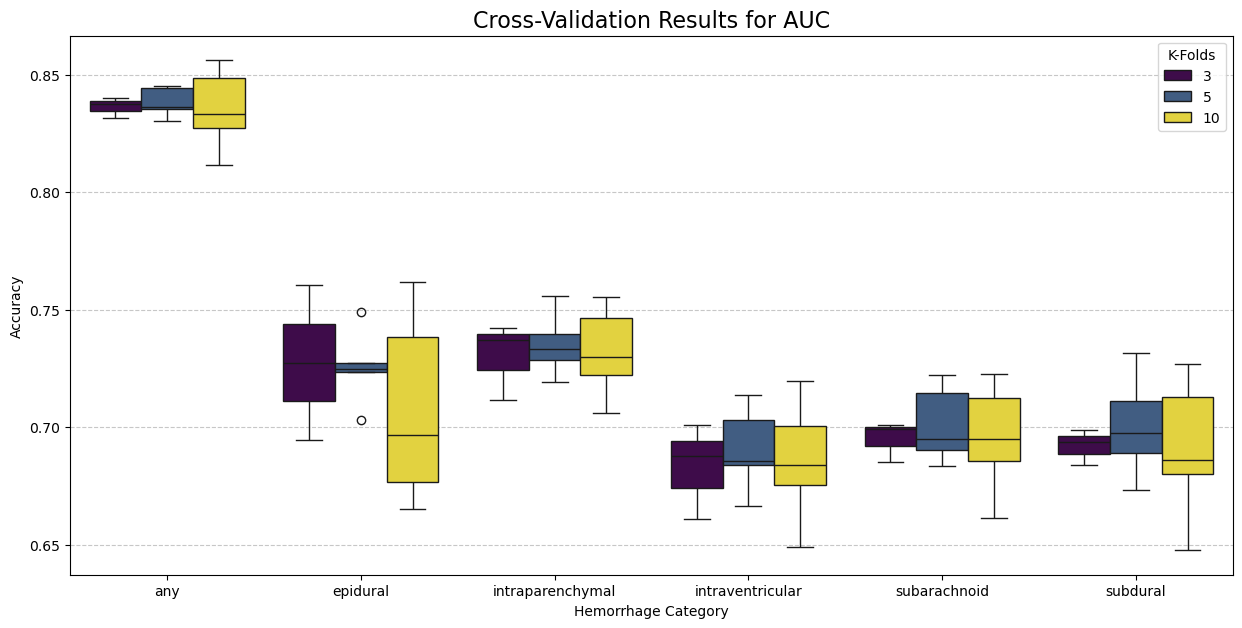

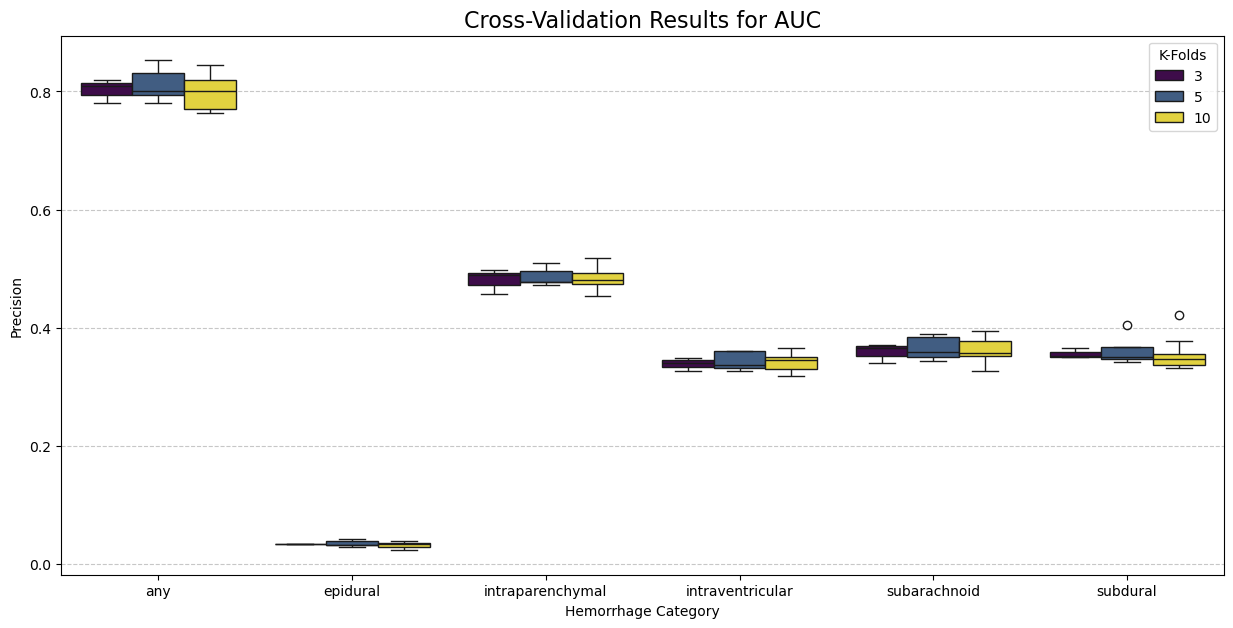

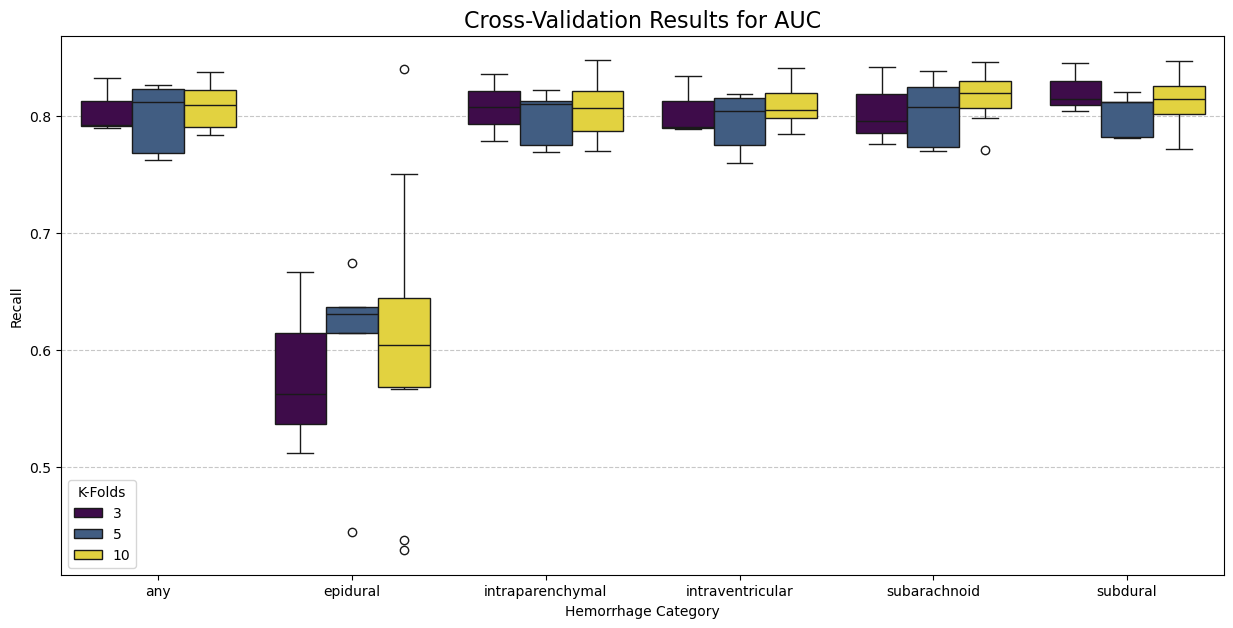

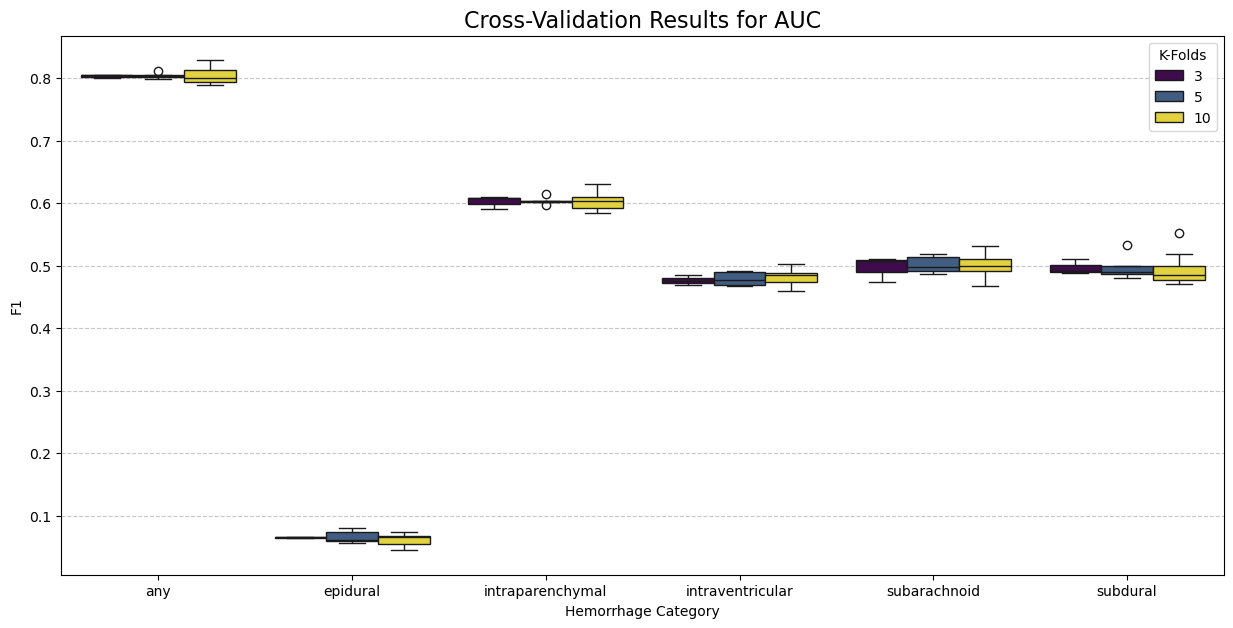

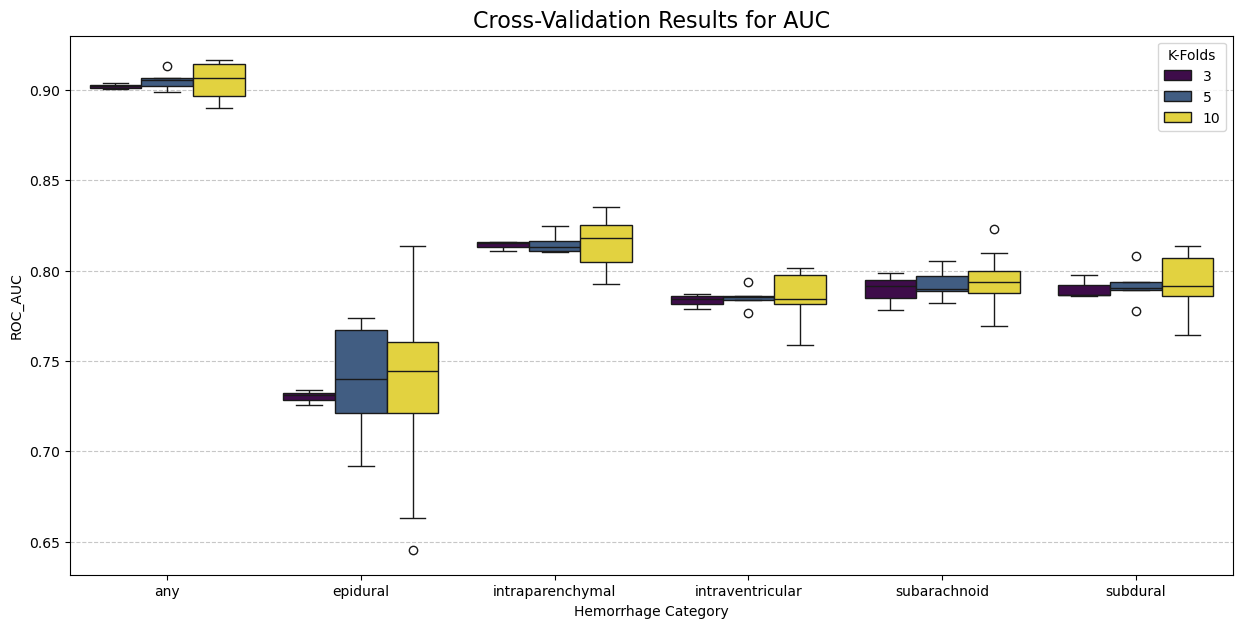

In [ ]:
# Convert the list of metrics into a DataFrame
results_df = pd.DataFrame(all_metrics_list)

print("\n" + "="*50)
print("CROSS-VALIDATION SUMMARY")
print("="*50)

# Calculate specificity for each fold/category
def calculate_specificity(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# Display the mean and standard deviation for each K
for k in k_folds_list:
    print(f"\n--- Summary for K={k} Folds (Mean ± Std Dev) ---")
    
    k_df = results_df[results_df['K'] == k]
    
    # Group by category and calculate mean/std
    summary = k_df.groupby('Category')[['Accuracy', 'ROC_AUC', 'Recall', 'F1']].agg(['mean', 'std'])
    
    # Format for easier reading
    formatted_summary = pd.DataFrame(index=summary.index)
    for metric in ['Accuracy', 'ROC_AUC', 'Recall', 'F1']:
        mean_col = summary[(metric, 'mean')]
        std_col = summary[(metric, 'std')]
        formatted_summary[metric] = mean_col.round(4).astype(str) + " ± " + std_col.round(4).astype(str)
        
    print(formatted_summary.rename(columns={'Recall': 'Sensitivity'}))

print("\n" + "="*50)
print("VISUALIZATIONS")
print("="*50)

# Create boxplots to visualize the spread of results for each metric
metrics_to_plot = ['Accuracy', 'ROC_AUC', 'Recall', 'F1']
metric_labels = {'Accuracy': 'Accuracy', 'ROC_AUC': 'AUC', 'Recall': 'Sensitivity', 'F1': 'F1 Score'}

for metric in metrics_to_plot:
    plt.figure(figsize=(15, 7))
    sns.boxplot(data=results_df, x='Category', y=metric, hue='K', palette='viridis')
    plt.title(f'Cross-Validation Results for {metric_labels[metric]}', fontsize=16)
    plt.ylabel(metric_labels[metric])
    plt.xlabel('Hemorrhage Category')
    plt.legend(title='K-Folds')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()